✅ Data Loaded: (15000, 20) features

🧠 GMM Model Evaluation:
AIC: 293503.34
BIC: 298773.47
Silhouette Score: 0.090

📁 Clustered data saved as gmm_clustered_results.csv

🔹 Cluster Counts:
Cluster
0    7875
2    4693
1    2432
Name: count, dtype: int64

🔹 Cluster Means (Feature Centroids):
           N_Days       Age       Sex   Ascites  Hepatomegaly   Spiders  \
Cluster                                                                   
0        0.129595  0.095498  0.086951 -0.274622      0.166150 -0.113366   
1       -0.402939  0.644329 -0.079968  0.474665      0.617156 -0.103132   
2       -0.008654 -0.494151 -0.104465  0.214844     -0.598626  0.243676   

            Edema  Bilirubin  Cholesterol   Albumin  ...  Alk_Phos      SGOT  \
Cluster                                              ...                       
0       -0.486017  -0.039069    -0.432488  0.160314  ... -0.480892 -0.220579   
1        1.878484  -0.197732     0.564925 -0.065180  ... -0.035449  0.822493   
2       -0.1579

C:\Users\user\AppData\Local\Temp\ipykernel_20844\2758921110.py:92: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
F:\BioLivera3\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


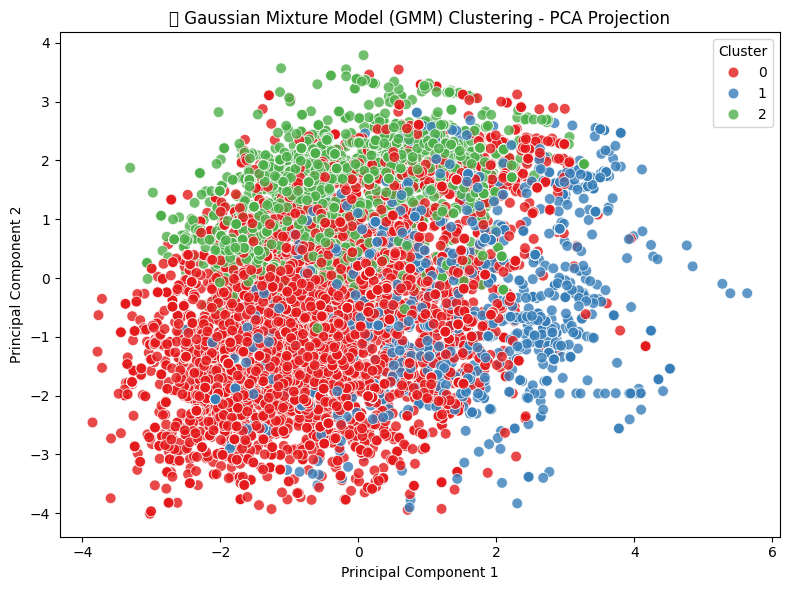

C:\Users\user\AppData\Local\Temp\ipykernel_20844\2758921110.py:103: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
F:\BioLivera3\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


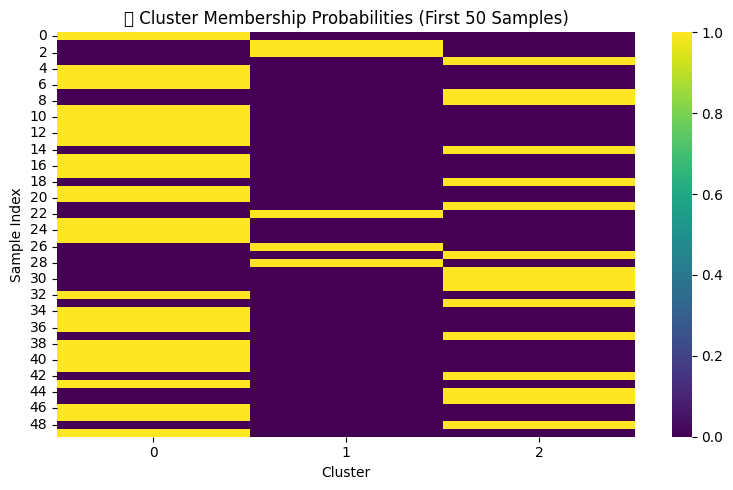

In [7]:
# =====================================
# Gaussian Mixture Model (GMM) Clustering for Liver Cirrhosis
# =====================================
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================
# 1️⃣ Load Scaled Dataset
# =====================================
data = pd.read_csv("../results/outputs/scaled.csv")

# Remove the target label (unsupervised learning)
if 'Status' in data.columns:
    X = data.drop(columns=['Status'])
else:
    X = data.copy()

print("✅ Data Loaded:", X.shape, "features")

# =====================================
# 2️⃣ Fit Gaussian Mixture Model
# =====================================
n_components = 3  # expected number of hidden subgroups
gmm = GaussianMixture(
    n_components=n_components,
    covariance_type='full',   # allows each cluster its own covariance matrix
    random_state=42,
    n_init=10
)

gmm.fit(X)
clusters = gmm.predict(X)
probs = gmm.predict_proba(X)

# =====================================
# 3️⃣ Evaluate Clustering Quality
# =====================================
aic = gmm.aic(X)
bic = gmm.bic(X)
silhouette = silhouette_score(X, clusters)

print("\n🧠 GMM Model Evaluation:")
print(f"AIC: {aic:.2f}")
print(f"BIC: {bic:.2f}")
print(f"Silhouette Score: {silhouette:.3f}")

# =====================================
# 4️⃣ Append Cluster Labels to Data
# =====================================
data_with_clusters = data.copy()
data_with_clusters["Cluster"] = clusters

# Save clustered dataset
data_with_clusters.to_csv("gmm_clustered_results.csv", index=False)
print("\n📁 Clustered data saved as gmm_clustered_results.csv")

# =====================================
# 5️⃣ Cluster Summary
# =====================================
print("\n🔹 Cluster Counts:")
print(data_with_clusters["Cluster"].value_counts())

print("\n🔹 Cluster Means (Feature Centroids):")
print(data_with_clusters.groupby("Cluster").mean())

# =====================================
# 6️⃣ 2D Visualization using PCA
# =====================================
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X)
pca_df = pd.DataFrame(pca_data, columns=["PC1", "PC2"])
pca_df["Cluster"] = clusters

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue="Cluster",
    palette="Set1",
    s=60,
    alpha=0.8
)
plt.title("🌀 Gaussian Mixture Model (GMM) Clustering - PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

# =====================================
# 7️⃣ Optional: Cluster Probability Visualization
# =====================================
plt.figure(figsize=(8,5))
sns.heatmap(probs[:50], cmap="viridis", cbar=True)
plt.title("🔍 Cluster Membership Probabilities (First 50 Samples)")
plt.xlabel("Cluster")
plt.ylabel("Sample Index")
plt.tight_layout()
plt.show()
